# Land Cover Statistics Extraction (LCFM)

© VITO NV, 2026. This notebook and its output figure are licensed under [Creative Commons Attribution 4.0 International (CC BY 4.0)](https://creativecommons.org/licenses/by/4.0/). You are free to share and adapt the material provided you give appropriate credit to VITO NV.

The goal of this notebook is to calculate land cover statistics per region, based on the LCFM Land Cover Map (LCM-10) for 2020.

For the definition of a region, it leverages data from Eurostat GISCO.

Two spatial units are supported:

| `SPATIAL_UNIT` | Dataset | Source |
|---|---|---|
| `"NUTS"` | NUTS 2024, Polygons (RG), 10M, EPSG:4326 | [GISCO – Territorial units for statistics](https://ec.europa.eu/eurostat/web/gisco/geodata/statistical-units/territorial-units-statistics) |
| `"COUNTRIES"` | Countries 2024, Polygons (RG), 20M, EPSG:4326 | [GISCO – Countries](https://ec.europa.eu/eurostat/web/gisco/geodata/administrative-units/countries) |

The NUTS hierarchy has three levels:
- **NUTS 1** – major socio-economic regions
- **NUTS 2** – basic regions for regional policy (default, `NUTS_LEVEL = 2`)
- **NUTS 3** – small regions for specific diagnoses

In [ ]:
COUNTRY_CODES = ["BE"] # ["BE", "NL", "LU", "DE", "FR", "IT"]
SPATIAL_UNIT = "NUTS" # "NUTS" or "COUNTRIES"
NUTS_LEVEL = 2 # NUTS level to use when SPATIAL_UNIT is "NUTS"

# Apply cos(latitude) area correction to account for pixel-area shrinkage toward the poles
# in WGS 84. Disable to get a simple unweighted mean (faster, useful for quick checks).
AREA_CORRECTION = True

# Suffix for file and job names
country_codes_str = "-".join(COUNTRY_CODES)
suffix = f"{SPATIAL_UNIT.lower()}_{country_codes_str}"
suffix


'nuts_BE'

In [2]:
import sys
from pathlib import Path

# Detect environment
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Install required packages in Google Colab
if IN_COLAB:
    %pip install -q openeo geopandas pandas matplotlib pyarrow

BASE_DIR = Path("/content") if IN_COLAB else Path("./")

In [3]:
import tempfile

import openeo
import openeo.processes as eop
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# Requires: pip install "openeo[artifacts]" --upgrade
from openeo.extra.artifacts import build_artifact_helper


In [5]:
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()


Authenticated using refresh token.


## Load geometries

Load the geometries of the regions to survey from the **Eurostat GISCO** geodata service.

Both datasets are cached locally in `/content/resources/` after the first download.

In [6]:
import requests

GISCO_BASE = "https://gisco-services.ec.europa.eu/distribution/v2"

SPATIAL_CONFIGS = {
    "NUTS": {
        "url": f"{GISCO_BASE}/nuts/geojson/NUTS_RG_01M_2024_4326.geojson",
        "cache": BASE_DIR / "resources/NUTS_RG_01M_2024_4326.geojson",
        "drop_columns": ["MOUNT_TYPE", "URBN_TYPE", "NAME_FREN", "COAST_TYPE", "SVRG_UN", "CAPT", "EU_STAT", "EFTA_STAT", "CC_STAT", "NAME_GERM"],
        "id_property": "NUTS_ID",
    },
    "COUNTRIES": {
        "url": f"{GISCO_BASE}/countries/geojson/CNTR_RG_20M_2024_4326.geojson",
        "cache": BASE_DIR / "resources/CNTR_RG_20M_2024_4326.geojson",
        "drop_columns": ["CNTR_NAME", "NAME_FREN", "ISO3_CODE", "SVRG_UN", "CAPT", "STAT_CODE", "EU_STAT", "EFTA_STAT", "CC_STAT", "NAME_GERM"],
        "id_property": "CNTR_ID",
    },
}
cfg = SPATIAL_CONFIGS[SPATIAL_UNIT]

if not cfg["cache"].exists():
    cfg["cache"].parent.mkdir(parents=True, exist_ok=True)
    # Use requests to download so Python's SSL context can be used
    response = requests.get(cfg["url"])
    response.raise_for_status()
    cfg["cache"].write_bytes(response.content)

In [7]:
spatial_geometries = gpd.read_file(cfg["cache"])
if cfg["drop_columns"]:
    spatial_geometries = spatial_geometries.drop(columns=cfg["drop_columns"])

# Partition the requested codes by length (2-letter vs 3-letter) so we can
# filter on the correct attribute for each.
codes_2 = [c for c in COUNTRY_CODES if len(c) == 2]
codes_3 = [c for c in COUNTRY_CODES if len(c) == 3]

if SPATIAL_UNIT == "NUTS":
    spatial_geometries = spatial_geometries[
        spatial_geometries["CNTR_CODE"].isin(codes_2)
        & (spatial_geometries["LEVL_CODE"] == NUTS_LEVEL)
    ]
    id_col = "NUTS_NAME"
elif SPATIAL_UNIT == "COUNTRIES":
    spatial_geometries = spatial_geometries[
        spatial_geometries["CNTR_ID"].isin(codes_2)
        | spatial_geometries.get("COUNTRY_URI", pd.Series(index=spatial_geometries.index, dtype=object)).isin(codes_3)
    ]
    id_col = "NAME_ENGL"

spatial_geometries

,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,NAME_ENGL,ISO3_CODE,geometry
1341,BE22,2,BE,Prov. Limburg (BE),Prov. Limburg (BE),Belgium,BEL,"MULTIPOLYGON (((5.55667 51.26513, 5.55627 51.2..."
1343,BE23,2,BE,Prov. Oost-Vlaanderen,Prov. Oost-Vlaanderen,Belgium,BEL,"MULTIPOLYGON (((4.29756 51.2429, 4.30027 51.23..."
1345,BE24,2,BE,Prov. Vlaams-Brabant,Prov. Vlaams-Brabant,Belgium,BEL,"MULTIPOLYGON (((5.1597 51.02415, 5.13202 51.01..."
1347,BE25,2,BE,Prov. West-Vlaanderen,Prov. West-Vlaanderen,Belgium,BEL,"MULTIPOLYGON (((3.38299 51.34115, 3.38471 51.3..."
1348,BE31,2,BE,Prov. Brabant wallon,Prov. Brabant wallon,Belgium,BEL,"MULTIPOLYGON (((4.76252 50.80338, 4.79639 50.7..."
1350,BE32,2,BE,Prov. Hainaut,Prov. Hainaut,Belgium,BEL,"MULTIPOLYGON (((3.71141 50.7738, 3.7171 50.768..."
1352,BE10,2,BE,Région de Bruxelles-Capitale/ Brussels Hoofdst...,Région de Bruxelles-Capitale/ Brussels Hoofdst...,Belgium,BEL,"MULTIPOLYGON (((4.41574 50.90617, 4.43148 50.8..."
1353,BE21,2,BE,Prov. Antwerpen,Prov. Antwerpen,Belgium,BEL,"MULTIPOLYGON (((4.8247 51.44761, 4.82703 51.43..."
1354,BE33,2,BE,Prov. Liège,Prov. Liège,Belgium,BEL,"MULTIPOLYGON (((5.69379 50.80972, 5.69354 50.8..."
1356,BE34,2,BE,Prov. Luxembourg (BE),Prov. Luxembourg (BE),Belgium,BEL,"MULTIPOLYGON (((5.45689 50.41056, 5.46678 50.4..."


**Data attribution:** © European Union, [Eurostat / GISCO](https://ec.europa.eu/eurostat/web/gisco), 2024.
Reproduction is authorised provided the source is acknowledged.
Geodata are provided under [Eurostat's general copyright notice and licence policy](https://ec.europa.eu/eurostat/about-us/policies/copyright).
The Commission accepts no responsibility for the accuracy or completeness of these datasets; only EU legislation published in the *Official Journal of the European Union* is deemed authentic.

# Retrieve Data

Supporting functions:

In [8]:
# Classes from https://stac.terrascope.be/collections/lcfm-lcm-10
LCFM_LEGEND = {
    "Tree_Cover": 10,
    "Shrubland": 20,
    "Grassland": 30,
    "Cropland": 40,
    "Herbaceous_Wetland": 50,
    "Mangroves": 60,
    "Moss_Lichen": 70,
    "Bare_Sparse_Vegetation": 80,
    "Built_Up": 90,
    "Permanent_Water_Bodies": 100,
    "Snow_Ice": 110,
    "Unclassifiable": 254,
}

def lcfm_to_masks(bands):
    lcfm_list = [bands[0] == value for value in LCFM_LEGEND.values()]

    return eop.array_create(lcfm_list)

Build the openEO process graph:

1. **Load** the `LCFM_LCM_10` collection for 2020 and collapse the time dimension by keeping the first (and only) annual map.
2. **Classify** – convert the single-band integer map into one binary mask per land cover class (using `lcfm_to_masks`), so each band is 1 where that class is present and 0 elsewhere.
3. **Area correction** (optional, controlled by `AREA_CORRECTION`) – append a `_weight` band equal to cos(latitude) for each pixel. Because the map is distributed in WGS 84 (EPSG:4326), pixels at higher latitudes cover a smaller real-world area; dividing by the sum of weights during post-processing corrects for this distortion.
4. **Geometries** – on CDSE the region polygons are uploaded as an artifact (presigned URL) instead of being embedded inline in the process graph. On other backends the GeoJSON is passed inline. Requires `openeo[artifacts]` to be available.
5. **Aggregate spatially** – run `aggregate_spatial` over the region polygons loaded from GISCO, summing the (weighted) class masks per polygon. With area correction the result is a weighted sum; without it a simple mean is used instead.


In [9]:

# Load in the LCFM LCM-10 data
lcfm = connection.load_collection("CLMS_LCM_GLOBAL_10M_YEARLY_V1",
                             temporal_extent=["2020-01-01", "2020-12-31"],
                             bands=["map"]).reduce_dimension(dimension="t", reducer="first")

classified = (
    lcfm.apply_dimension(dimension="bands", process=lcfm_to_masks)
    .apply(lambda x: x * 1)
    .rename_labels(
        dimension="bands",
        target=list(LCFM_LEGEND.keys())
    )
)

# Upload the GeoJSON as an artifact so it is not embedded in the process graph.
artifact_helper = build_artifact_helper(connection)
with tempfile.NamedTemporaryFile(mode="w", suffix=".geojson", delete=False) as tmp:
    tmp.write(spatial_geometries.to_json())
    tmp_geojson = Path(tmp.name)
storage_uri = artifact_helper.upload_file(tmp_geojson, f"geometries_{suffix}.geojson")
presigned_uri = artifact_helper.get_presigned_url(storage_uri)
geoms = presigned_uri

if AREA_CORRECTION:
    # Area correction for WGS 84: pixel area ∝ cos(latitude).
    # Assumption: the 'y' coordinate in the UDF chunk is latitude in degrees (EPSG:4326).
    _add_cos_lat_weight = openeo.UDF("""
import numpy as np
import xarray as xr

def apply_datacube(cube: xr.DataArray, context: dict) -> xr.DataArray:
    # 'y' coordinate is latitude in degrees for EPSG:4326 data
    w = np.cos(np.deg2rad(cube.coords["y"])).clip(min=0)
    # Reuse first-band slice as spatial template for the weight band (avoids expand_dims)
    w_band = cube.isel(bands=slice(0, 1)) * 0 + w
    return xr.concat([cube * w, w_band], dim="bands")
""")

    classified = classified.apply_dimension(
        process=_add_cos_lat_weight,
        dimension="bands",
    ).rename_labels(
        dimension="bands",
        target=list(LCFM_LEGEND.keys()) + ["_weight"],
    )
    aggregator = "sum"
else:
    aggregator = "mean"

# Note: aggregate_spatial considers all pixels for which the point at the pixel center intersects with the corresponding polygon
average = classified.aggregate_spatial(geoms, aggregator)


Start job

In [10]:
# Execute the data cube processing and save the result
use_large_job_options = SPATIAL_UNIT == "COUNTRIES" or (SPATIAL_UNIT == "NUTS" and NUTS_LEVEL == 0)
job_options = {
    "executor-memory": "6G",
    "executor-memoryOverhead": "6G",
    "max-executors": 20,
    "do_extent_check": False,
} if use_large_job_options else {}

job = average.execute_batch(
    out_format="Parquet",
    title=f"land-cover-lcfm_{suffix}",
    feature_id_property=cfg["id_property"],
    job_options=job_options,
)


0:00:00 Job 'j-26060307460745628a96976e6e647c58': send 'start'
0:00:19 Job 'j-26060307460745628a96976e6e647c58': queued (progress 0%)
0:00:25 Job 'j-26060307460745628a96976e6e647c58': queued (progress 0%)
0:00:31 Job 'j-26060307460745628a96976e6e647c58': queued (progress 0%)
0:00:39 Job 'j-26060307460745628a96976e6e647c58': queued (progress 0%)
0:00:49 Job 'j-26060307460745628a96976e6e647c58': queued (progress 0%)
0:01:01 Job 'j-26060307460745628a96976e6e647c58': running (progress N/A)
0:01:16 Job 'j-26060307460745628a96976e6e647c58': running (progress N/A)
0:01:35 Job 'j-26060307460745628a96976e6e647c58': running (progress N/A)
0:01:59 Job 'j-26060307460745628a96976e6e647c58': running (progress N/A)
0:02:29 Job 'j-26060307460745628a96976e6e647c58': running (progress N/A)
0:03:07 Job 'j-26060307460745628a96976e6e647c58': running (progress N/A)
0:03:53 Job 'j-26060307460745628a96976e6e647c58': running (progress N/A)
0:04:52 Job 'j-26060307460745628a96976e6e647c58': running (progress N/A

You can also check the job in the [openEO Web Editor – CDSE](https://editor.openeo.org/?server=https%3A%2F%2Fopeneo.dataspace.copernicus.eu%2F).


Download result

In [11]:
# job = connection.job("j-...")
results_dir = BASE_DIR / "results"
results_dir.mkdir(parents=True, exist_ok=True)
country_codes_str = "-".join(COUNTRY_CODES)
job.get_results().get_asset("timeseries.parquet").download(results_dir / f"timeseries_{suffix}.parquet")

PosixPath('results/timeseries_nuts_BE.parquet')

# Visualize data

In [12]:
result_file = Path(results_dir / f"timeseries_{suffix}.parquet")
df = pd.read_parquet(result_file)
df.drop(columns=['geometry'], errors='ignore').head()

,id,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,NAME_ENGL,ISO3_CODE,feature_index,Tree_Cover,...,Cropland,Herbaceous_Wetland,Mangroves,Moss_Lichen,Bare_Sparse_Vegetation,Built_Up,Permanent_Water_Bodies,Snow_Ice,Unclassifiable,_weight
0,1341,BE22,2,BE,Prov. Limburg (BE),Prov. Limburg (BE),Belgium,BEL,0,1.049687e+07,...,6.303607e+06,18514.195345,0.0,0.0,22591.900970,4.481898e+06,402649.495895,0.0,0.0,2.815861e+07
1,1343,BE23,2,BE,Prov. Oost-Vlaanderen,Prov. Oost-Vlaanderen,Belgium,BEL,1,7.371442e+06,...,1.087652e+07,34962.492219,0.0,0.0,10608.119448,6.595220e+06,584014.152901,0.0,0.0,3.490068e+07
2,1345,BE24,2,BE,Prov. Vlaams-Brabant,Prov. Vlaams-Brabant,Belgium,BEL,2,7.945634e+06,...,7.355216e+06,5474.614947,0.0,0.0,1177.479942,4.014711e+06,86179.611046,0.0,0.0,2.459652e+07
3,1347,BE25,2,BE,Prov. West-Vlaanderen,Prov. West-Vlaanderen,Belgium,BEL,3,4.381866e+06,...,1.651094e+07,30756.252211,0.0,0.0,68179.599484,6.191810e+06,342674.479736,0.0,0.0,3.679304e+07
4,1348,BE31,2,BE,Prov. Brabant wallon,Prov. Brabant wallon,Belgium,BEL,4,3.571579e+06,...,6.254997e+06,210.013633,0.0,0.0,8723.097196,1.248275e+06,30537.340217,0.0,0.0,1.273434e+07


In [13]:

# Load the data
df = pd.read_parquet(result_file)
df[id_col] = df[id_col].str.split('/').str[-1]

land_cover_columns = list(LCFM_LEGEND.keys())

if AREA_CORRECTION:
    # Area correction: the job produced weighted sums per class.
    # Specifically, the result contains the following columns:
    #   df[class]     = Σ cos(lat) over pixels of that class in the region
    #   df["_weight"] = Σ cos(lat) over ALL pixels in the region
    # These are dimensionless "equator-equivalent pixel counts", NOT areas in m².
    # Dividing by the sum of weights yields the area-corrected class fraction.
    df[land_cover_columns] = df[land_cover_columns].div(df["_weight"], axis=0)
    df = df.drop(columns=["_weight"])

# Consistency check: fractions should sum to ~1 per region
row_sums = df[land_cover_columns].sum(axis=1)
assert (row_sums - 1).abs().lt(1e-9).all(), (
    f"Land cover fractions do not sum to 1 (max deviation: {(row_sums - 1).abs().max():.6f})"
)

# Multiply by 100
df[land_cover_columns] = df[land_cover_columns] * 100
# Remove classes with zero coverage across all regions
land_cover_columns = [lc for lc in land_cover_columns if df[lc].sum() > 0]

# Colors derived from classification:classes color_hint in the STAC collection
colors = {
    'Tree_Cover':             (0x00/255, 0x64/255, 0x00/255),  # #006400
    'Shrubland':              (0xFF/255, 0xBB/255, 0x22/255),  # #FFBB22
    'Grassland':              (0xFF/255, 0xFF/255, 0x4C/255),  # #FFFF4C
    'Cropland':               (0xF0/255, 0x96/255, 0xFF/255),  # #F096FF
    'Herbaceous_Wetland':     (0x00/255, 0x96/255, 0xA0/255),  # #0096A0
    'Mangroves':              (0x00/255, 0xCF/255, 0x75/255),  # #00CF75
    'Moss_Lichen':            (0xFA/255, 0xE6/255, 0xA0/255),  # #FAE6A0
    'Bare_Sparse_Vegetation': (0xB4/255, 0xB4/255, 0xB4/255),  # #B4B4B4
    'Built_Up':               (0xFA/255, 0x00/255, 0x00/255),  # #FA0000
    'Permanent_Water_Bodies': (0x00/255, 0x64/255, 0xC8/255),  # #0064C8
    'Snow_Ice':               (0xF0/255, 0xF0/255, 0xFF/255),  # #F0F0FF
    'Unclassifiable':         (0x68/255, 0x68/255, 0x68/255),  # #686868
}


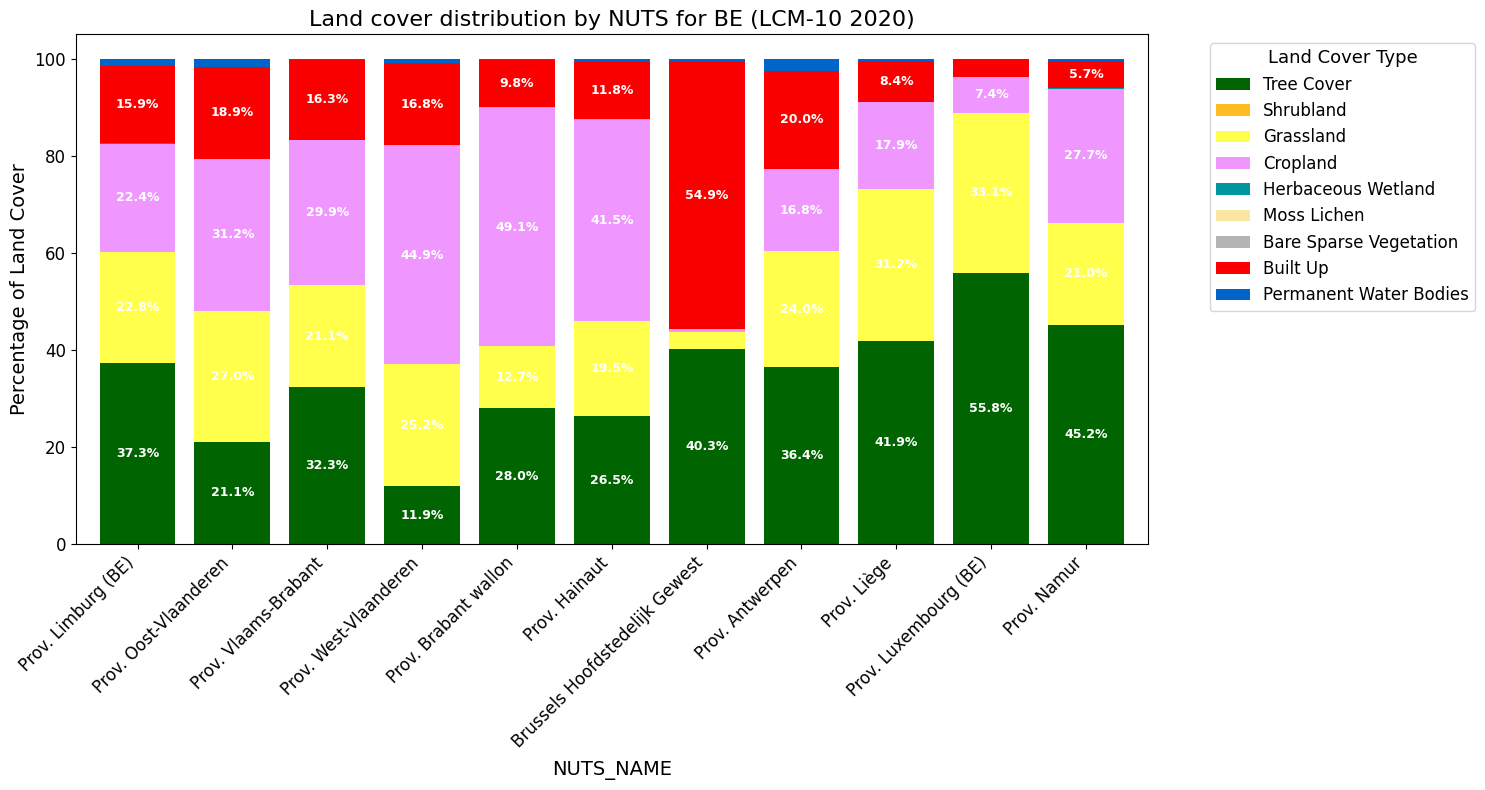

In [14]:
# Plot the data
fig, ax = plt.subplots(figsize=(15, 8))
df.set_index(id_col)[land_cover_columns].plot(
    kind='bar',
    stacked=True,
    color=[colors[col] for col in land_cover_columns],
    width=0.8,
    ax=ax
)

# Direct labeling: annotate each bar segment with its percentage (only if > 5%)
for container, col in zip(ax.containers, land_cover_columns):
    labels = [f'{bar.get_height():.1f}%' if bar.get_height() > 5 else '' for bar in container]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=9, color='white', fontweight='bold')

# Customize the plot
ax.set_xlabel(id_col, fontsize=14)
ax.set_ylabel('Percentage of Land Cover', fontsize=14)
ax.set_title(f'Land cover distribution by {SPATIAL_UNIT} for {", ".join(COUNTRY_CODES)} (LCM-10 2020)', fontsize=16)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, [l.replace('_', ' ') for l in labels], title='Land Cover Type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, title_fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()


Limitations of the demo:
- Countries with higher details (scale lower than 20M not tested)
- Upscaling to large regions (e.g. US) does not succeed currently.